<h1>Problem statement: </h1>
<p>Predict the next day closing price of Tesla shares.<p>


<h1>Introduction</h1>
<h1>Table of content</h1>
<h1>Step 1: Import libraries</h1>
<h1>Step 2: Download stock data</h1>
<h1>Step 3: View data</h1>
<h1>Step 4: Input-Output feature division</h1>
<h1>Step 5: Training Phase with Cross validation Evaluation</h1>
<h2>5.1: Models used</h2>
<h2>5.2: Cross-Validator initializations</h2>
<h2>5.3: Cross-validation with LinearRegression</h2>
<h3>5.3.1: Mean Squared Error with single-fold cross validation</h3>
<h3>5.3.2: Mean Absolute Error with single-fold cross validation</h3>
<h3>5.3.3: Mean Squared Error with k-fold cross validation</h3>
<h3>5.3.4: Mean Absolute Error with k-fold cross validation</h3>
<h3>5.3.5: R^2 Error with k-fold cross validation</h3>
<h2>5.4: Cross-validation with RandomForests</h2>
<h3>5.4.1: Mean Squared Error with single-fold cross validation</h3>
<h3>5.4.2: Mean Absolute Error with single-fold cross validation</h3>
<h3>5.4.3: Mean Squared Error with k-fold cross validation</h3>
<h3>5.4.4: Mean Absolute Error with k-fold cross validation</h3>
<h3>5.4.5: R^2 Error with k-fold cross validation</h3>
<h2>5.5: Best CV-results</h2>
<h2>5.6: Comparison between Actual and Predicted value</h2>
<h1>Step 6: Saving the model</h1>
<h1>Step 7: Model Application testing phase</h1>

<h1>Step 1: Import libraries</h1>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut, cross_val_predict
import matplotlib.pyplot as plt
import joblib

<h1>Step 2: Download Tesla data</h1>

In [2]:
tesla_data = yf.download("TSLA")


/tmp/ipykernel_6555/2669178630.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download("TSLA")
[*********************100%***********************]  1 of 1 completed


<h1>Step 3: View data</h1>

In [3]:
#print(tesla_data.columns)
#print(type(tesla_data))

#print(tesla_data.index)
print(tesla_data)

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2026-03-24  383.029999  387.480011  376.309998  376.559998   60004900
2026-03-25  385.950012  396.230011  385.010010  389.989990   55157300
2026-03-26  372.109985  384.440002  371.869995  381.600006   55522900
2026-03-27  361.829987  369.859985  359.470001  369.690002   62065700
2026-03-30  355.279999  367.290009  352.140015  365.859985   67954400
2026-03-31  371.750000  373.329987  361.000000  361.510010   75534900
2026-04-01  381.260010  383.140015  374.079987  378.630005   58683800
2026-04-02  360.589996  370.279999  359.029999  364.200012   83031200
2026-04-06  352.820007  367.720001  346.640015  362.589996   77697600
2026-04-07  346.649994  348.019989  337.239990  346.440002   74515400
2026-04-08  343.250000  364.500000  339.670013  363.790009   78838600
2026-04-09  345.6199

<h1>Step 4: Input-Output feature division</h1>

In [4]:
X = tesla_data[["Low", "High", "Open", "Volume"]]
y = tesla_data[["Close"]]

<h3>View input</h3>

In [5]:
print(X)

Price              Low        High        Open     Volume
Ticker            TSLA        TSLA        TSLA       TSLA
Date                                                     
2026-03-24  376.309998  387.480011  376.559998   60004900
2026-03-25  385.010010  396.230011  389.989990   55157300
2026-03-26  371.869995  384.440002  381.600006   55522900
2026-03-27  359.470001  369.859985  369.690002   62065700
2026-03-30  352.140015  367.290009  365.859985   67954400
2026-03-31  361.000000  373.329987  361.510010   75534900
2026-04-01  374.079987  383.140015  378.630005   58683800
2026-04-02  359.029999  370.279999  364.200012   83031200
2026-04-06  346.640015  367.720001  362.589996   77697600
2026-04-07  337.239990  348.019989  346.440002   74515400
2026-04-08  339.670013  364.500000  363.790009   78838600
2026-04-09  337.250000  348.880005  343.149994   62164000
2026-04-10  342.739990  350.359985  346.290009   51336000
2026-04-13  348.570007  356.350006  350.070007   53617500
2026-04-14  35

<h3>View Output</h3>

In [6]:
print(y)

Price            Close
Ticker            TSLA
Date                  
2026-03-24  383.029999
2026-03-25  385.950012
2026-03-26  372.109985
2026-03-27  361.829987
2026-03-30  355.279999
2026-03-31  371.750000
2026-04-01  381.260010
2026-04-02  360.589996
2026-04-06  352.820007
2026-04-07  346.649994
2026-04-08  343.250000
2026-04-09  345.619995
2026-04-10  348.950012
2026-04-13  352.420013
2026-04-14  364.200012
2026-04-15  391.950012
2026-04-16  388.899994
2026-04-17  400.619995
2026-04-20  392.500000
2026-04-21  386.420013
2026-04-22  387.510010
2026-04-23  373.720001


<h1>Step 5: Training Phase with Cross validation Evaluation</h1>

<h2>5.1: Models used</h2>

In [7]:
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)

<h2>5.2: Cross-Validator initializations</h2>

In [8]:
# initialization of single-fold cross-validation
loo = LeaveOneOut()
# initialization of k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

<h2>5.3: Cross-validation with LinearRegression</h2>

<h3>5.3.1: Mean Squared Error with single-fold cross validation</h3>

In [9]:
# calculate MSE score
lr_mse_scores = cross_val_score(lr_model, X, y, cv=loo, scoring="neg_mean_squared_error")
# Calculate mean and standard deviation
mean_score = -np.mean(lr_mse_scores)
std_score = np.std(lr_mse_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
# Print values
print("Cross-validation scores:", lr_mse_scores)
print("Mean MSE:", mean_score)
print("Mean RMSE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


Cross-validation scores: [-3.52187542e+00 -1.52666793e+01 -9.49372730e+00 -9.80257247e-01
 -5.93015293e-01 -4.22364278e-01 -1.78254828e+01 -3.58518019e+01
 -5.10218274e+00 -5.52403624e+01 -2.18413573e+01 -1.09437031e+00
 -1.65906304e+00 -1.01970246e+01 -1.90574364e-02 -2.06697302e+02
 -7.12360156e+01 -1.48300405e+00 -3.41841618e-01 -2.67937763e+00
 -6.05013561e-01 -3.16846668e+01]
Mean MSE: 22.447083772375606
Mean RMSE:  4.737835346693214
Standard deviation: 44.37938230962631
Root Standard deviation: 6.661785219415762


<h3>5.3.2: Mean Absolute Error with single-fold cross validation</h3>

In [10]:
# calculate MAE score
lr_mae_scores = cross_val_score(lr_model, X, y, cv=loo, scoring="neg_mean_absolute_error")
# Calculate mean and standard deviation
mean_score = -np.mean(lr_mae_scores)
std_score = np.std(lr_mae_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
# Print values
print("Cross-validation scores:", lr_mae_scores)
print("Mean MAE:", mean_score)
print("Mean RMAE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)

Cross-validation scores: [ -1.87666604  -3.90725982  -3.08118927  -0.99007941  -0.77007486
  -0.64989559  -4.22202354  -5.98763742  -2.25880117  -7.43238605
  -4.67347379  -1.04612156  -1.28804621  -3.19327804  -0.13804867
 -14.37697125  -8.4401431   -1.21778654  -0.58467223  -1.63688046
  -0.77782618  -5.62891347]
Mean MAE: 3.3717352124615805
Mean RMAE:  1.8362285294759966
Standard deviation: 3.328435883327523
Root Standard deviation: 1.8244001434245511


<h3>5.3.3: Mean Squared Error with k-fold cross validation</h3>

In [11]:
# calculate MSE score
lr_kf_mse_scores = cross_val_score(lr_model, X, y, cv=kf, scoring="neg_mean_squared_error")
# Calculate mean and standard deviation
mean_score = -np.mean(lr_kf_mse_scores)
std_score = np.std(lr_kf_mse_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
#Print values
print("Cross-validation scores:", lr_kf_mse_scores)
print("Mean MSE:", mean_score)
print("Mean RMSE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


Cross-validation scores: [-44.049382    -0.71698633 -21.66142629 -26.93997445 -13.9422362 ]
Mean MSE: 21.46200105299065
Mean RMSE:  4.632709903824181
Standard deviation: 14.332761354739848
Root Standard deviation: 3.7858633565858986


<h3>5.3.4: Mean Absolute Error with k-fold cross validation</h3>

In [12]:

# calculate MAE score
lr_kf_mae_scores = cross_val_score(lr_model, X, y, cv=kf, scoring="neg_mean_absolute_error")
# Calculate mean and standard deviation
mean_score = -np.mean(lr_kf_mae_scores)
std_score = np.std(lr_kf_mae_scores)
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
#Print values
print("Cross-validation scores:", lr_kf_mae_scores)
print("Mean MAE:", mean_score)
print("Mean RMAE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


Cross-validation scores: [-4.5472625  -0.82093517 -3.05567773 -4.8986379  -3.14453139]
Mean MAE: 3.2934089395769233
Mean RMAE:  1.8147751760416284
Standard deviation: 1.4381040260040976
Root Standard deviation: 1.199209750629179


<h3>5.3.5: R^2 Error with k-fold cross validation</h3>

In [13]:
# calculate R^2 score
lr_r2_scores = cross_val_score(lr_model, X, y, cv=kf, scoring="r2")

# Calculate mean and standard deviation
mean_score = np.mean(lr_r2_scores)
std_score = np.std(lr_r2_scores)
#Print values
print("Cross-validation scores:", lr_r2_scores)
print("Mean R2:", mean_score)
print("Standard deviation:", std_score)


Cross-validation scores: [0.84892874 0.99652139 0.94566511 0.77109127 0.95106605]
Mean R2: 0.9026545110100624
Standard deviation: 0.08148610092421744


<h2>5.4: Cross-validation with RandomForests</h2>

<h3>5.4.1: Mean Squared Error with single-fold cross validation</h3>

In [ ]:
# calculate MSE score
rf_mse_scores = cross_val_score(rf_model, X, y, cv=loo, scoring="neg_mean_squared_error")

# Calculate mean and standard deviation
mean_score = -np.mean(rf_mse_scores)
std_score = np.std(rf_mse_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
#Print values
print("Cross-validation scores:", rf_mse_scores)
print("Mean MSE:", mean_score)
print("Mean RMSE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


<h3>5.4.2: Mean Absolute Error with single-fold cross validation</h3>

In [ ]:
# calculate MAE score
rf_mae_scores = cross_val_score(rf_model, X, y, cv=loo, scoring="neg_mean_absolute_error")

# Calculate mean and standard deviation
mean_score = -np.mean(rf_mae_scores)
std_score = np.std(rf_mae_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
#Print values
print("Cross-validation scores:", rf_mae_scores)
print("Mean MAE:", mean_score)
print("Mean RMAE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


<h3>5.4.3: Mean Squared Error with k-fold cross validation</h3>

In [ ]:
# calculate MSE score
rf_kf_mse_scores = cross_val_score(rf_model, X, y, cv=kf, scoring="neg_mean_squared_error")
# Calculate mean and standard deviation
mean_score = -np.mean(rf_kf_mse_scores)
std_score = np.std(rf_kf_mse_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
#Print values
print("Cross-validation scores:", rf_kf_mse_scores)
print("Mean MSE:", mean_score)
print("Mean RMSE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


<h3>5.4.4: Mean Absolute Error with k-fold cross validation</h3>

In [ ]:
# calculate MAE score
rf_kf_mae_scores = cross_val_score(rf_model, X, y, cv=kf, scoring="neg_mean_absolute_error")

# Calculate mean and standard deviation
mean_score = -np.mean(rf_kf_mae_scores)
std_score = np.std(rf_kf_mae_scores)
# Calculate root mean and root standard deviation
rmean_score = np.sqrt(mean_score)
rstd_score = np.sqrt(std_score)
#Print values
print("Cross-validation scores:", rf_kf_mae_scores)
print("Mean MAE:", mean_score)
print("Mean RMAE: ", rmean_score )
print("Standard deviation:", std_score)
print("Root Standard deviation:", rstd_score)


<h3>5.4.5: R^2 Error with k-fold cross validation</h3>

In [ ]:
# calculate R^2 score
r2_scores = cross_val_score(rf_model, X, y, cv=kf, scoring="r2")
# Calculate mean and standard deviation
mean_score = np.mean(r2_scores)
std_score = np.std(r2_scores)
#Print values
print("Cross-validation scores:", r2_scores)
print("Mean R2:", mean_score)
print("Standard deviation:", std_score)

<h2>5.5: Best CV-results</h2> Model: LinearRegression<br>C.V. fold: k-fold cross validation<br>Choice of error: Mean Absolute Error<br>R^2 value is 0.9 for this model which depicts better performance to variations in the output<br>

<h2>So by using LinearRegression with k-fold cross validation we get the following predicted values: </h2>

In [18]:
lr_kf_predictions = cross_val_predict(lr_model, X,y,cv=kf)
print(f"Predictions: {lr_kf_predictions}")

Predictions: [[384.19908047]
 [390.05246735]
 [374.59839919]
 [360.86472731]
 [355.86865296]
 [371.02591163]
 [376.45273852]
 [367.0410933 ]
 [352.86769221]
 [342.58463339]
 [348.47473999]
 [344.46789102]
 [348.52023224]
 [356.11008195]
 [363.95647699]
 [378.22298994]
 [379.96236204]
 [400.31113168]
 [389.95356434]
 [384.11743429]
 [388.18457972]
 [380.30968151]]


<h2>5.6: Comparison between Actual and Predicted value</h2>

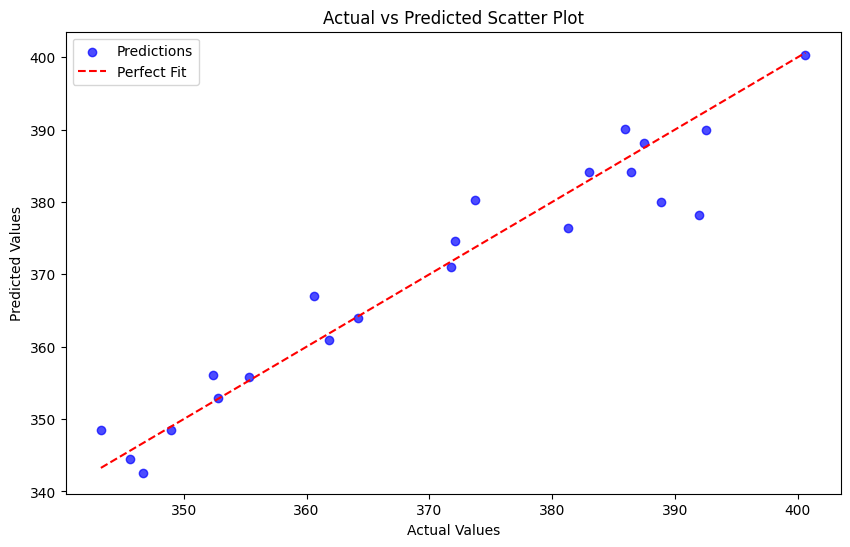

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(y, lr_kf_predictions, alpha=0.7, color="blue", label="Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit")  # diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")
plt.legend()
plt.show()



<h1>Plot interpretation</h1>
<p>The predicted points are close to the red line(actual points) so the training model fits the data well as shows less variance from actual values.  </p>

<h1>Step 6: Saving the model</h1>

In [20]:
model = LinearRegression()
model.fit(X, y)
# save the model
joblib.dump(model, "final_model.pkl")

['final_model.pkl']

<h1>Step 7: Model Application testing phase</h1>

In [24]:
# Load the model later
loaded_model = joblib.load("final_model.pkl")
# User input
high_price_input = input("Enter high price: ")
low_price_input =  input("Enter low price: ")
open_price_input = input("Enter opening price: ")
shares_volume = input("Enter shares amount: ")
#converted to feature vector
user_input = pd.DataFrame({
    'high_price':[high_price_input],
    'low_price':[low_price_input],
    'open_price':[open_price_input],
    'volume':[shares_volume],
})
print(f"User input: {user_input}\n")
new_predictions = loaded_model.predict(user_input.values)
print(f"Closing Price Prediction: {new_predictions}") # Closing price prediction on basis of high, low, open prices and volume of shares

Enter high price: 600
Enter low price: 400
Enter opening price: 550
Enter shares amount: 78967850
User input:   high_price low_price open_price    volume
0        600       400        550  78967850

Closing Price Prediction: [[431.96086042]]
